In [ ]:


# STEP 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from google.colab import files

In [ ]:


# STEP 2: UPLOAD DATASET


uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Saving hospital_readmission_dataset.csv to hospital_readmission_dataset (3).csv
Dataset loaded successfully!
Dataset Shape: (8000, 17)


,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [ ]:


# STEP 3: DATASET OVERVIEW


print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Rows:")
display(df.head())

DATASET OVERVIEW
Number of Rows: 8000
Number of Columns: 17

Column Names:
['patient_id', 'admission_date', 'season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'readmission_risk_score', 'label']

Data Types:
patient_id                    object
admission_date                object
season                        object
age                            int64
gender                        object
region                        object
primary_diagnosis             object
comorbidities_count            int64
length_of_stay                 int64
treatment_type                object
medications_count              int64
followup_visits_last_year      int64
prev_readmissions              int64
insurance_type                object
discharge_disposition         object
readmission_risk_score       float64
label                

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [ ]:


# STEP 4: DATA QUALITY CHECK


print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Missing values
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Duplicate patient IDs
print("\nDuplicate Patient IDs:")
print(df["patient_id"].duplicated().sum())

# Target values
print("\nTarget Values:")
print(df["label"].unique())

# Target distribution
print("\nTarget Distribution:")
display(df["label"].value_counts())

print("\nData quality check completed.")

DATA QUALITY CHECK

Missing Values:


,Missing Values
patient_id,0
admission_date,0
season,0
age,0
gender,0
region,0
primary_diagnosis,0
comorbidities_count,0
length_of_stay,0
treatment_type,0



Duplicate Rows:
0

Duplicate Patient IDs:
0

Target Values:
[1 0]

Target Distribution:


,count
label,
1,6183
0,1817



Data quality check completed.


Target Distribution:
label
1    6183
0    1817
Name: count, dtype: int64

Target Percentage:
label
1    77.29
0    22.71
Name: proportion, dtype: float64


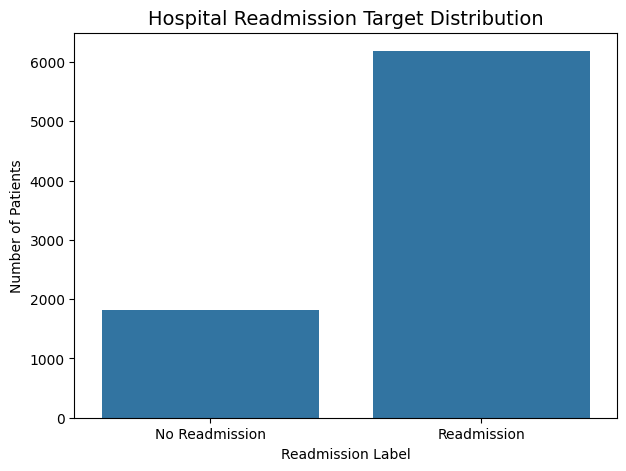

In [ ]:


# STEP 5: TARGET DISTRIBUTION


target_counts = df["label"].value_counts()

print("Target Distribution:")
print(target_counts)

print("\nTarget Percentage:")
print(
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title(
    "Hospital Readmission Target Distribution",
    fontsize=14
)

plt.xlabel("Readmission Label")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Readmission", "Readmission"]
)

plt.show()

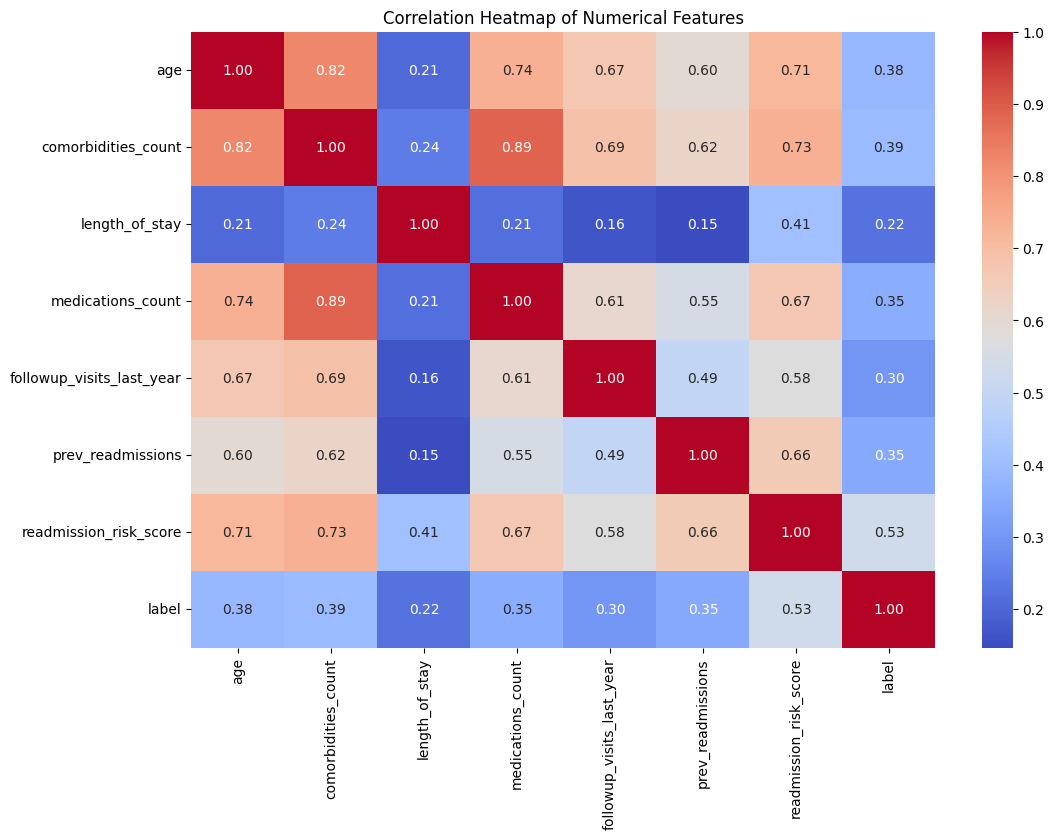

In [ ]:


# STEP 6: CORRELATION HEATMAP


numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)

plt.show()

In [ ]:

# STEP 7: FEATURE ENGINEERING


# Convert admission date to datetime
df["admission_date"] = pd.to_datetime(
    df["admission_date"],
    errors="coerce"
)

# Extract date features
df["admission_year"] = df[
    "admission_date"
].dt.year

df["admission_month"] = df[
    "admission_date"
].dt.month

df["admission_day"] = df[
    "admission_date"
].dt.day

# Remove identifier and original date
df = df.drop(
    columns=[
        "patient_id",
        "admission_date"
    ]
)

print("Feature engineering completed.")

display(df.head())

Feature engineering completed.


,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label,admission_year,admission_month,admission_day
0,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1,2022,4,14
1,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1,2021,9,19
2,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1,2023,4,12
3,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1,2023,8,14
4,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1,2021,11,5


In [ ]:


# STEP 8: SEPARATE FEATURES AND TARGET


X = df.drop(
    columns=["label"]
)

y = df["label"]

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature Shape: (8000, 17)
Target Shape: (8000,)

Features:
['season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'readmission_risk_score', 'admission_year', 'admission_month', 'admission_day']


In [ ]:


# STEP 9: IDENTIFY FEATURE TYPES


numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'comorbidities_count', 'length_of_stay', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'readmission_risk_score']

Categorical Features:
['season', 'gender', 'region', 'primary_diagnosis', 'treatment_type', 'insurance_type', 'discharge_disposition']


In [ ]:


# STEP 10: TRAIN / VALIDATION / TEST SPLIT




X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 15% Validation
# 15% Testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set:", X_train.shape)
print("Validation Set:", X_val.shape)
print("Testing Set:", X_test.shape)

print("\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation Target Distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Set: (5600, 17)
Validation Set: (1200, 17)
Testing Set: (1200, 17)

Train Target Distribution:
label
1    0.772857
0    0.227143
Name: proportion, dtype: float64

Validation Target Distribution:
label
1    0.773333
0    0.226667
Name: proportion, dtype: float64

Test Target Distribution:
label
1    0.7725
0    0.2275
Name: proportion, dtype: float64


In [ ]:


# STEP 11: PREPROCESSING PIPELINE


# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:


# STEP 12: DEFINE MACHINE LEARNING MODELS


models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

}

print("Models defined successfully.")

Models defined successfully.


In [ ]:


# STEP 13: TRAIN AND VALIDATE MODELS


results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    # Complete pipeline
    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )

    # Train model
    pipeline.fit(
        X_train,
        y_train
    )

    # Validation predictions
    y_val_pred = pipeline.predict(
        X_val
    )

    y_val_prob = pipeline.predict_proba(
        X_val
    )[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val,
        y_val_pred
    )

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob
    )

    # Save results
    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Balanced Accuracy": balanced_accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc

    })

    # Save trained pipeline
    trained_models[
        model_name
    ] = pipeline

    print("Training completed.")

# Create results table
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(
    drop=True
)

print("\nMODEL COMPARISON:")
display(results_df)


Training: Logistic Regression
Training completed.

Training: Random Forest
Training completed.

MODEL COMPARISON:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.780833,0.790726,0.932380,0.772629,0.845021,0.863172
1,Random Forest,0.808333,0.668167,0.842829,0.924569,0.881809,0.842708


In [ ]:


# STEP 14: SELECT BEST MODEL


best_model_name = results_df.loc[
    0,
    "Model"
]

best_model = trained_models[
    best_model_name
]

print("BEST MODEL:")
print(best_model_name)

print(
    "\nBest Validation ROC-AUC:",
    round(
        results_df.loc[
            0,
            "ROC-AUC"
        ],
        4
    )
)

BEST MODEL:
Logistic Regression

Best Validation ROC-AUC: 0.8632


In [ ]:




# Combine training and validation data
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
)

y_train_final = pd.concat(
    [
        y_train,
        y_val
    ],
    axis=0
)

# Refit the best pipeline
best_model.fit(
    X_train_final,
    y_train_final
)

print(
    "Best model successfully refitted using "
    "training + validation data."
)

Best model successfully refitted using training + validation data.


In [ ]:


# STEP 16: FINAL TEST EVALUATION


# Predictions
y_test_pred = best_model.predict(
    X_test
)

# Probabilities
y_test_prob = best_model.predict_proba(
    X_test
)[:, 1]

# Metrics
final_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        y_test_pred
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        y_test_pred
    ),

    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_prob
    )

}

final_results_df = pd.DataFrame(
    final_metrics.items(),
    columns=[
        "Metric",
        "Score"
    ]
)

final_results_df["Score"] = final_results_df[
    "Score"
].round(4)

display(final_results_df)

,Metric,Score
0,Accuracy,0.7475
1,Balanced Accuracy,0.7552
2,Precision,0.9160
3,Recall,0.7411
4,F1 Score,0.8193
5,ROC-AUC,0.8369


In [ ]:


# STEP 17: CLASSIFICATION REPORT


print(
    classification_report(
        y_test,
        y_test_pred,

        target_names=[
            "No Readmission",
            "Readmission"
        ],

        zero_division=0
    )
)

                precision    recall  f1-score   support

No Readmission       0.47      0.77      0.58       273
   Readmission       0.92      0.74      0.82       927

      accuracy                           0.75      1200
     macro avg       0.69      0.76      0.70      1200
  weighted avg       0.81      0.75      0.77      1200



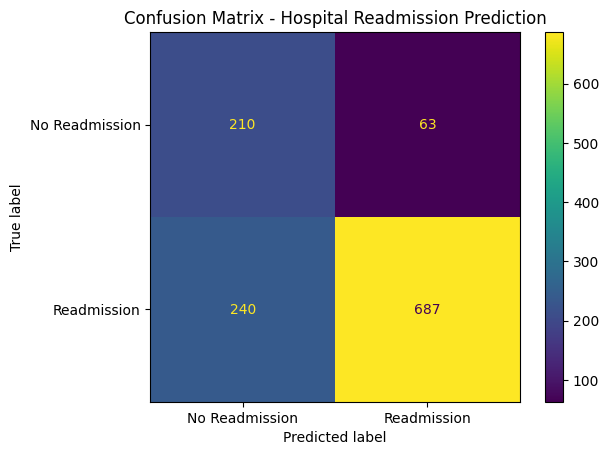

In [ ]:


# STEP 18: CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        "No Readmission",
        "Readmission"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Hospital Readmission Prediction"
)

plt.show()

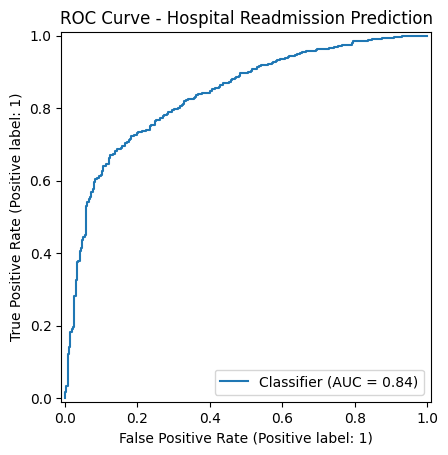

In [ ]:


# STEP 19: ROC CURVE


RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title(
    "ROC Curve - Hospital Readmission Prediction"
)

plt.show()

In [ ]:


# STEP 20: SAVE COMPLETE PIPELINE


model_filename = (
    "hospital_readmission_prediction_pipeline.pkl"
)

joblib.dump(
    best_model,
    model_filename
)

print(
    "Complete model pipeline saved successfully."
)

print(
    "File:",
    model_filename
)

Complete model pipeline saved successfully.
File: hospital_readmission_prediction_pipeline.pkl


In [ ]:


# STEP 22: PREDICTION FUNCTION


def predict_readmission(

    season,
    age,
    gender,
    region,
    primary_diagnosis,
    comorbidities_count,
    length_of_stay,
    treatment_type,
    medications_count,
    followup_visits_last_year,
    prev_readmissions,
    insurance_type,
    discharge_disposition,
    readmission_risk_score,
    admission_year,
    admission_month,
    admission_day

):

    # Create input data
    input_data = pd.DataFrame({

        "season": [season],

        "age": [age],

        "gender": [gender],

        "region": [region],

        "primary_diagnosis": [
            primary_diagnosis
        ],

        "comorbidities_count": [
            comorbidities_count
        ],

        "length_of_stay": [
            length_of_stay
        ],

        "treatment_type": [
            treatment_type
        ],

        "medications_count": [
            medications_count
        ],

        "followup_visits_last_year": [
            followup_visits_last_year
        ],

        "prev_readmissions": [
            prev_readmissions
        ],

        "insurance_type": [
            insurance_type
        ],

        "discharge_disposition": [
            discharge_disposition
        ],

        "readmission_risk_score": [
            readmission_risk_score
        ],

        "admission_year": [
            admission_year
        ],

        "admission_month": [
            admission_month
        ],

        "admission_day": [
            admission_day
        ]

    })

    # Prediction
    prediction = best_model.predict(
        input_data
    )[0]

    # Probability
    probability = best_model.predict_proba(
        input_data
    )[0][1]

    probability_percentage = (
        probability * 100
    )

    # Final output
    if prediction == 1:

        return {
            "Prediction":
            "HIGH RISK - Hospital Readmission Likely",

            "Readmission Probability":
            f"{probability_percentage:.2f}%"
        }

    else:

        return {
            "Prediction":
            "LOW RISK - Hospital Readmission Unlikely",

            "Readmission Probability":
            f"{probability_percentage:.2f}%"
        }

In [ ]:


# STEP 23: GET ACTUAL CATEGORIES


season_choices = sorted(
    df["season"]
    .dropna()
    .unique()
    .tolist()
)

gender_choices = sorted(
    df["gender"]
    .dropna()
    .unique()
    .tolist()
)

region_choices = sorted(
    df["region"]
    .dropna()
    .unique()
    .tolist()
)

diagnosis_choices = sorted(
    df["primary_diagnosis"]
    .dropna()
    .unique()
    .tolist()
)

treatment_choices = sorted(
    df["treatment_type"]
    .dropna()
    .unique()
    .tolist()
)

insurance_choices = sorted(
    df["insurance_type"]
    .dropna()
    .unique()
    .tolist()
)

discharge_choices = sorted(
    df["discharge_disposition"]
    .dropna()
    .unique()
    .tolist()
)

print("Actual dataset categories loaded successfully.")

Actual dataset categories loaded successfully.


In [ ]:


# STEP 24: FINAL GRADIO DEPLOYMENT


import gradio as gr

demo = gr.Interface(

    fn=predict_readmission,

    inputs=[

        gr.Dropdown(
            choices=season_choices,
            label="Season",
            value=season_choices[0]
        ),

        gr.Number(
            label="Age",
            value=float(
                df["age"].median()
            )
        ),

        gr.Dropdown(
            choices=gender_choices,
            label="Gender",
            value=gender_choices[0]
        ),

        gr.Dropdown(
            choices=region_choices,
            label="Region",
            value=region_choices[0]
        ),

        gr.Dropdown(
            choices=diagnosis_choices,
            label="Primary Diagnosis",
            value=diagnosis_choices[0]
        ),

        gr.Number(
            label="Comorbidities Count",
            value=float(
                df[
                    "comorbidities_count"
                ].median()
            )
        ),

        gr.Number(
            label="Length of Stay",
            value=float(
                df[
                    "length_of_stay"
                ].median()
            )
        ),

        gr.Dropdown(
            choices=treatment_choices,
            label="Treatment Type",
            value=treatment_choices[0]
        ),

        gr.Number(
            label="Medications Count",
            value=float(
                df[
                    "medications_count"
                ].median()
            )
        ),

        gr.Number(
            label="Follow-up Visits Last Year",
            value=float(
                df[
                    "followup_visits_last_year"
                ].median()
            )
        ),

        gr.Number(
            label="Previous Readmissions",
            value=float(
                df[
                    "prev_readmissions"
                ].median()
            )
        ),

        gr.Dropdown(
            choices=insurance_choices,
            label="Insurance Type",
            value=insurance_choices[0]
        ),

        gr.Dropdown(
            choices=discharge_choices,
            label="Discharge Disposition",
            value=discharge_choices[0]
        ),

        gr.Number(
            label="Readmission Risk Score",
            value=float(
                df[
                    "readmission_risk_score"
                ].median()
            )
        ),

        gr.Number(
            label="Admission Year",
            value=2023
        ),

        gr.Number(
            label="Admission Month",
            value=6
        ),

        gr.Number(
            label="Admission Day",
            value=15
        )

    ],

    outputs=gr.JSON(
        label="Prediction Result"
    ),

    title=(
        "Hospital Readmission Prediction System"
    ),

    description=(
        "A Data-Driven Machine Learning Approach "
        "for Hospital Readmission Prediction"
    ),

    theme=gr.themes.Soft()

)

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://afd1c196063f6e5ad7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
